# KL-Annealed Joint Bayesian Operator Inference: Compressible Euler

**Model A + KL Annealing** — single-shot joint inference with a β schedule that
ramps the KL penalty from 0 → 1 over the first ~30–40% of SVI iterations.

### Why this works

The null basin problem (Model A) occurs because the GP can fit the data
independently of the operator, collapsing to flat states with O = 0. KL
annealing prevents this by exploiting a natural ordering:

- **β ≈ 0 phase**: The GP chases the data hard (no prior regularisation pulls
  it toward over-smoothing). The operator drifts gently toward matching whatever
  derivatives the GP produces — it gets weak signal because Σ_z (the derivative
  covariance) is still large.
- **β ramp-up**: Priors kick in, regularising both GP hyperparameters and the
  operator.
- **β = 1 phase**: We optimise the true ELBO; both components refine together.

The key insight: once the GP has structure (non-flat states), the operator
follows naturally through the physics coupling. The model's own uncertainty
structure creates a built-in curriculum.

In [41]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import jax
import jax.numpy as jnp
import opinf
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO, Predictive, autoguide
from numpyro.optim import Adam, ClippedAdam
from jax import random
import time

from core import (
    generate_trajectory,
    JaxCompatibleModel,
    compute_gp_derivatives,
    compute_derivatives_fourth_order,
    generate_rom_predictions,
    DataScaler,
    build_joint_bayesian_model,
    extract_gp_posterior,
    extract_derivative_posterior,
    gp_based_opinf_baseline,
    rbf_eval,
    SVIResult,
)
from core.bayesian_opinf import _find_operator_samples

sys.path.insert(0, '../euler')
import config
from config import Basis

numpyro.set_platform('cpu')
numpyro.set_host_device_count(4)

np.random.seed(42)
rng_key = random.PRNGKey(42)

In [42]:
# === EXPERIMENT CONFIGURATION ===
OPERATORS = "cAH"
IVP_METHOD = "RK45"
NUM_MODES = 6

# Data generation
TRAINING_SPAN = (0, 0.08)
PREDICTION_SPAN = (0, config.time_domain[-1])
NUM_SAMPLES = 250
NOISE_LEVEL = 0.03
NUM_EVAL_POINTS = 400

# Data scaling
USE_SCALED_DATA = True

# Inference settings
GUIDE = autoguide.AutoNormal
VERBOSE = True

# Hyperparameters
GAMMA = 1e4      # Operator prior scale (weakly informative)
GAMMA2 = 1e1     # ODE constraint slack

# GP hyperparameter priors (LogNormal)
GP_LENGTHSCALE_PRIOR_LOC = None          # defaults to log(T/20)
GP_LENGTHSCALE_PRIOR_SCALE = 0.5
GP_VARIANCE_PRIOR_LOC = None             # defaults to log(var(data))
GP_VARIANCE_PRIOR_SCALE = 0.5
GP_NOISE_PRIOR_LOC = None  # computed per-mode after POD compression (see below)
GP_NOISE_PRIOR_SCALE = 0.25

# ODE constraint slack — hierarchical prior
LEARN_GAMMA2 = True
GAMMA2_PRIOR_LOC = None
GAMMA2_PRIOR_SCALE = 1.0

# === KL ANNEALING CONFIGURATION ===
# NUM_SVI_STEPS = 80000
NUM_SVI_STEPS = 40000
LEARNING_RATE = 1e-3
NUM_POSTERIOR_SAMPLES = 1000

# β schedule: ramps from BETA_START → 1.0 over the first ANNEAL_FRACTION of iterations
BETA_START = 0.0            # small positive floor keeps priors weakly active
# ANNEAL_FRACTION = 0.70       # extended ramp — β=1 only for final 30% of training
ANNEAL_FRACTION = 0.6       # ramp duration (60% of steps after delay → 12k steps)
ANNEAL_DELAY = 0.125          # β=0 for first 30% of steps (GP converges alone)
ANNEAL_SCHEDULE = "stepwise" # "linear", "cosine", or "stepwise"
ANNEAL_ONLY = False         # run full annealing + refinement

# Plotting
NUM_REGRESSION_POINTS = 150

## 1. Generate Training Data

In [43]:
(fom, time_domain_full, true_states, time_sampled, snapshots_sampled) = \
    generate_trajectory(config, config.time_domain, TRAINING_SPAN, NUM_SAMPLES, NOISE_LEVEL)

print(f"Full time domain: {time_domain_full.shape}")
print(f"Sampled times: {time_sampled.shape}")
print(f"Training span: [{TRAINING_SPAN[0]:.4f}, {TRAINING_SPAN[1]:.4f}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]:.4f}, {PREDICTION_SPAN[1]:.4f}]")

generating training data...done in 1.27 s.
Full time domain: (401,)
Sampled times: (250,)
Training span: [0.0000, 0.0800]
Prediction span: [0.0000, 0.1500]


In [44]:
basis = Basis(num_vectors=NUM_MODES)
basis.fit(snapshots_sampled)

snapshots_comp_sampled = basis.compress(snapshots_sampled)
print(f"Compressed shape: {snapshots_comp_sampled.shape}")
print(f"Cumulative energy: {basis.cumulative_energy:.4%}")

# Evaluation time domains
time_domain_eval_training = np.linspace(TRAINING_SPAN[0], TRAINING_SPAN[1], NUM_REGRESSION_POINTS)
time_domain_eval_prediction = np.linspace(PREDICTION_SPAN[0], PREDICTION_SPAN[1], NUM_REGRESSION_POINTS)
full_states_compressed = basis.compress(true_states)

Compressed shape: (6, 250)
Cumulative energy: 88.2756%


In [45]:
if USE_SCALED_DATA:
    data_scaler = DataScaler(num_modes=NUM_MODES)
    data_scaler.fit(snapshots_comp_sampled)
    training_data = data_scaler.transform(snapshots_comp_sampled)
    print(f"Scaling enabled: {data_scaler}")
else:
    data_scaler = None
    training_data = snapshots_comp_sampled
    print("Scaling disabled: using raw POD coefficients")

# Compute per-mode noise priors from the actual data.
# Noise was added as relative: noise_std = NOISE_LEVEL * |signal|.
# After POD compression, each mode has different signal magnitude,
# so we estimate the noise variance per mode from the data.
per_mode_noise_var = np.array([
    (NOISE_LEVEL * np.std(snapshots_comp_sampled[i])) ** 2
    for i in range(NUM_MODES)
])
GP_NOISE_PRIOR_LOC = np.log(per_mode_noise_var)

print("\nPer-mode noise priors (data-driven):")
for i in range(NUM_MODES):
    sig_std = np.std(snapshots_comp_sampled[i])
    noise_std = np.sqrt(per_mode_noise_var[i])
    snr = sig_std / noise_std if noise_std > 0 else float('inf')
    print(f"  Mode {i}: signal_std={sig_std:.4f}, noise_std={noise_std:.6f}, "
          f"noise_var={per_mode_noise_var[i]:.8f}, SNR={snr:.1f}")

Scaling enabled: DataScaler(num_modes=6, fitted=True, mean_range=[-4.974e-17, 1.386e-16], std_range=[1.993e-01, 4.724e-01])

Per-mode noise priors (data-driven):
  Mode 0: signal_std=0.4724, noise_std=0.014171, noise_var=0.00020082, SNR=33.3
  Mode 1: signal_std=0.3855, noise_std=0.011566, noise_var=0.00013377, SNR=33.3
  Mode 2: signal_std=0.2599, noise_std=0.007797, noise_var=0.00006080, SNR=33.3
  Mode 3: signal_std=0.2364, noise_std=0.007092, noise_var=0.00005030, SNR=33.3
  Mode 4: signal_std=0.2251, noise_std=0.006753, noise_var=0.00004560, SNR=33.3
  Mode 5: signal_std=0.1993, noise_std=0.005978, noise_var=0.00003573, SNR=33.3


## 2. Build ROM Structure

In [46]:
rom = opinf.ROM(
    basis=basis,
    ddt_estimator=opinf.ddt.NonuniformFiniteDifferencer(time_sampled),
    model=JaxCompatibleModel(operators=OPERATORS, solver=opinf.lstsq.L2Solver(regularizer=1e0))
)
rom.fit(states=snapshots_sampled)
print(f"Operator shape: {rom.model.operator_matrix.shape}")

Operator shape: (6, 28)


## 3. KL-Annealed Joint Bayesian Inference

### β schedule

We anneal the KL penalty weight β from 0 → 1:
- **β = 0**: Only likelihood terms active (observation + ODE constraint). The GP
  gets strong signal from data; the operator gets weak signal because derivative
  covariance Σ_z is still large.
- **β ramp**: Priors gradually regularise. The GP tightens, Σ_z shrinks, and the
  operator starts getting sharper gradient signal.
- **β = 1**: True ELBO. Both components refine together.

Implementation: we scale each prior site's log-probability by β using
`numpyro.factor`, leaving the observation and ODE constraint likelihoods
at full strength throughout.

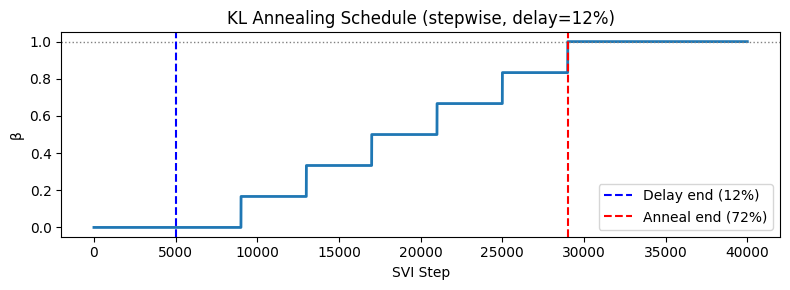

In [47]:
# === β schedule functions (with delay) ===
# Schedule: β=0 for [0, delay], ramp from 0→1 over [delay, delay+anneal], β=1 after.

def beta_schedule_linear(step, num_steps, anneal_fraction, beta_start=0.0, delay_fraction=0.0):
    """Linear ramp with optional delay."""
    delay_end = int(num_steps * delay_fraction)
    if step < delay_end:
        return beta_start
    anneal_steps = int(num_steps * anneal_fraction)
    anneal_end = delay_end + anneal_steps
    if step >= anneal_end:
        return 1.0
    t = (step - delay_end) / anneal_steps
    return beta_start + (1.0 - beta_start) * t


def beta_schedule_cosine(step, num_steps, anneal_fraction, beta_start=0.0, delay_fraction=0.0):
    """Cosine ramp with optional delay."""
    delay_end = int(num_steps * delay_fraction)
    if step < delay_end:
        return beta_start
    anneal_steps = int(num_steps * anneal_fraction)
    anneal_end = delay_end + anneal_steps
    if step >= anneal_end:
        return 1.0
    t = (step - delay_end) / anneal_steps
    return beta_start + (1.0 - beta_start) * 0.5 * (1.0 - np.cos(np.pi * t))


def beta_schedule_stepwise(step, num_steps, anneal_fraction, beta_start=0.0,
                          delay_fraction=0.0, num_stairs=6):
    """Stepwise β: β=0 during delay, then discrete staircase up to 1.0."""
    delay_end = int(num_steps * delay_fraction)
    anneal_steps = int(num_steps * anneal_fraction)
    anneal_end = delay_end + anneal_steps
    if step < delay_end:
        return beta_start
    if step >= anneal_end:
        return 1.0
    progress = (step - delay_end) / max(anneal_steps, 1)
    stair = int(progress * num_stairs)
    return beta_start + (1.0 - beta_start) * (stair / num_stairs)


SCHEDULE_FN = {
    "linear": beta_schedule_linear,
    "cosine": beta_schedule_cosine,
    "stepwise": beta_schedule_stepwise,
}[ANNEAL_SCHEDULE]

# Preview the schedule
steps_preview = np.arange(NUM_SVI_STEPS)
betas_preview = [SCHEDULE_FN(s, NUM_SVI_STEPS, ANNEAL_FRACTION, BETA_START, ANNEAL_DELAY) for s in steps_preview]
delay_end = int(NUM_SVI_STEPS * ANNEAL_DELAY)
anneal_end = delay_end + int(NUM_SVI_STEPS * ANNEAL_FRACTION)

fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(steps_preview, betas_preview, lw=2)
ax.axhline(1.0, color='gray', ls=':', lw=1)
ax.axvline(delay_end, color='blue', ls='--', lw=1.5, label=f'Delay end ({ANNEAL_DELAY:.0%})')
ax.axvline(anneal_end, color='red', ls='--', lw=1.5, label=f'Anneal end ({ANNEAL_DELAY+ANNEAL_FRACTION:.0%})')
ax.set_xlabel('SVI Step')
ax.set_ylabel('β')
ax.set_title(f'KL Annealing Schedule ({ANNEAL_SCHEDULE}, delay={ANNEAL_DELAY:.0%})')
ax.legend()
plt.tight_layout()
plt.show()

In [48]:
def build_annealed_joint_model(
    rom,
    num_modes,
    time_domain_sampled,
    snapshots,
    inputs_eval=None,
    data_scaler=None,
    gp_lengthscale_prior_loc=None,
    gp_lengthscale_prior_scale=1.0,
    gp_variance_prior_loc=None,
    gp_variance_prior_scale=0.5,
    gp_noise_prior_loc=None,
    gp_noise_prior_scale=1.0,
    gamma2_prior_loc=None,
    gamma2_prior_scale=1.0,
    learn_gamma2=True,
    num_eval_points=None,
):
    """
    Build a joint Bayesian model with KL annealing support.

    Uses the GP **marginal likelihood** approach: X is analytically
    marginalised via  y ~ N(0, K + νI),  then recovered deterministically
    as the GP conditional mean  X = K @ (K + νI)^{-1} y.
    This eliminates the 250-dim X_raw funnel that AutoNormal can't navigate.

    Returns (model, time_eval) where model has signature:
        model(gamma, gamma2, jitter, beta)
    """
    t_train = jnp.array(time_domain_sampled)
    n_train = len(t_train)
    T = float(t_train[-1] - t_train[0])
    y_obs = jnp.array(snapshots)                    # (num_modes, n_train)
    use_scaled = data_scaler is not None

    # Evaluation time points
    if num_eval_points is not None:
        time_eval = jnp.linspace(float(t_train[0]), float(t_train[-1]), num_eval_points)
    else:
        time_eval = t_train
    n_eval = len(time_eval)

    inputs_eval_jnp = jnp.array(inputs_eval) if inputs_eval is not None else None

    # ---------- Default GP priors ----------
    if gp_lengthscale_prior_loc is None:
        gp_lengthscale_prior_loc = jnp.full(num_modes, jnp.log(T / 20.0))
    else:
        gp_lengthscale_prior_loc = jnp.broadcast_to(
            jnp.asarray(gp_lengthscale_prior_loc, dtype=float), (num_modes,)
        )
    if gp_variance_prior_loc is None:
        gp_variance_prior_loc = jnp.array([
            jnp.log(jnp.var(y_obs[i]) + 1e-8) for i in range(num_modes)
        ])
    else:
        gp_variance_prior_loc = jnp.broadcast_to(
            jnp.asarray(gp_variance_prior_loc, dtype=float), (num_modes,)
        )
    if gp_noise_prior_loc is None:
        gp_noise_prior_loc = jnp.full(num_modes, -8.0)
    else:
        gp_noise_prior_loc = jnp.broadcast_to(
            jnp.asarray(gp_noise_prior_loc, dtype=float), (num_modes,)
        )

    _learn_gamma2 = learn_gamma2
    _gamma2_prior_scale = gamma2_prior_scale
    _gamma2_prior_loc = gamma2_prior_loc

    op_shape = rom.model.operator_matrix.shape

    # ---------- Precompute distance matrices ----------
    sq_diff_tt = (t_train[:, None] - t_train[None, :]) ** 2
    I_train = jnp.eye(n_train)
    I_eval = jnp.eye(n_eval)

    if num_eval_points is not None:
        diffs_et = time_eval[:, None] - t_train[None, :]
        sq_diffs_et = diffs_et ** 2
        sq_diffs_ee = (time_eval[:, None] - time_eval[None, :]) ** 2
    else:
        diffs_et = t_train[:, None] - t_train[None, :]
        sq_diffs_et = sq_diff_tt
        sq_diffs_ee = sq_diff_tt

    if use_scaled:
        scale_stds = jnp.array([data_scaler.stds_[i, 0] for i in range(num_modes)])
        scale_means = jnp.array([data_scaler.means_[i, 0] for i in range(num_modes)])

    # ---------- Kernel helpers ----------
    def _rbf_sq(ell, sig2, sq_diffs):
        return sig2 * jnp.exp(-sq_diffs / (2.0 * ell ** 2))

    def _single_marginal_gp(ell, sig2, nu, y_i, base_jitter):
        """Cholesky of K_y = K + (nu + jitter)*I  and  K_inv_y."""
        K = _rbf_sq(ell, sig2, sq_diff_tt)
        K_y = K + (nu + base_jitter) * I_train
        L_y = jnp.linalg.cholesky(K_y)
        K_inv_y = jax.scipy.linalg.cho_solve((L_y, True), y_i)
        X_i = K @ K_inv_y                           # GP posterior mean
        return L_y, K_inv_y, X_i, K

    def _single_interp_and_deriv(ell, sig2, L_y, K_inv_y):
        """Interpolate X to eval points and compute derivative statistics."""
        ell2 = ell ** 2
        K_et = _rbf_sq(ell, sig2, sq_diffs_et)
        X_eval_i = K_et @ K_inv_y

        # Derivative cross-kernel  K_zy  and self-kernel  K_zz
        K_zy = -(diffs_et / ell2) * K_et
        mu_z_i = K_zy @ K_inv_y

        K_ee = _rbf_sq(ell, sig2, sq_diffs_ee)
        K_zz = ((1.0 - sq_diffs_ee / ell2) / ell2) * K_ee

        # Derivative covariance:  A = K_zz - V^T V  where V = L_y^{-1} K_zy^T
        V = jax.scipy.linalg.solve_triangular(L_y, K_zy.T, lower=True)
        A_i = K_zz - V.T @ V
        A_i = 0.5 * (A_i + A_i.T)
        return X_eval_i, mu_z_i, A_i

    _batch_marginal_gp = jax.vmap(
        _single_marginal_gp, in_axes=(0, 0, 0, 0, None)
    )
    _batch_interp_deriv = jax.vmap(_single_interp_and_deriv)

    # ================================================================
    # The model function with β-annealing
    # ================================================================
    def model(gamma=1.0, gamma2=1.0, jitter=1e-4, beta=1.0):

        def _scaled_sample(name, prior_dist):
            x = numpyro.sample(name, prior_dist.mask(False))
            numpyro.factor(f"{name}_kl_scale", beta * prior_dist.log_prob(x))
            return x

        # --- γ₂ per mode (β-scaled) ---
        if _learn_gamma2:
            g2_loc = _gamma2_prior_loc if _gamma2_prior_loc is not None else jnp.log(gamma2)
            gamma2_arr = jnp.stack([
                _scaled_sample(f"gamma2_{i}", dist.LogNormal(g2_loc, _gamma2_prior_scale))
                for i in range(num_modes)
            ])
        else:
            gamma2_arr = jnp.full(num_modes, gamma2)

        # --- GP hyperparameters (full strength — not β-scaled) ---
        ells = jnp.stack([
            numpyro.sample(f"lengthscale_{i}",
                           dist.LogNormal(gp_lengthscale_prior_loc[i], gp_lengthscale_prior_scale))
            for i in range(num_modes)
        ])
        sig2s = jnp.stack([
            numpyro.sample(f"variance_{i}",
                           dist.LogNormal(gp_variance_prior_loc[i], gp_variance_prior_scale))
            for i in range(num_modes)
        ])
        nus = jnp.stack([
            numpyro.sample(f"noise_{i}",
                           dist.LogNormal(gp_noise_prior_loc[i], gp_noise_prior_scale))
            for i in range(num_modes)
        ])

        # --- GP marginal likelihood (full strength — not β-scaled) ---
        # Analytically marginalises X:  y ~ N(0, K + νI)
        L_ys, K_inv_ys, Xs, Ks = _batch_marginal_gp(ells, sig2s, nus, y_obs, jitter)

        for i in range(num_modes):
            K_y_i = Ks[i] + (nus[i] + jitter) * I_train
            numpyro.sample(
                f"obs_{i}",
                dist.MultivariateNormal(jnp.zeros(n_train), K_y_i),
                obs=y_obs[i],
            )
            numpyro.deterministic(f"X_{i}", Xs[i])

        # --- Interpolation + derivative conditioning ---
        Xs_eval_interp, mu_zs, As = _batch_interp_deriv(ells, sig2s, L_ys, K_inv_ys)

        if num_eval_points is not None:
            Xs_eval = Xs_eval_interp
            for i in range(num_modes):
                numpyro.deterministic(f"X_eval_{i}", Xs_eval[i])
        else:
            Xs_eval = Xs

        # --- Operator O (β-scaled prior) ---
        O = _scaled_sample(
            "O",
            dist.Normal(jnp.zeros(op_shape), gamma * jnp.ones(op_shape)),
        )

        # --- Transform to original space if scaled ---
        if use_scaled:
            Xs_eval_original = Xs_eval * scale_stds[:, None] + scale_means[:, None]
        else:
            Xs_eval_original = Xs_eval

        # --- Compute operator dynamics:  f(X) @ O^T ---
        f_Xi = rom.model._assemble_data_matrix(
            Xs_eval_original, inputs=inputs_eval_jnp
        ) @ O.T

        if use_scaled:
            f_Xi_scaled = f_Xi.T / scale_stds[:, None]
        else:
            f_Xi_scaled = f_Xi.T

        # --- ODE constraints (β-scaled, full covariance) ---
        for i in range(num_modes):
            numpyro.deterministic(f"mu_z_{i}", mu_zs[i])
            g2_eff = jnp.maximum(gamma2_arr[i], 1e-2) + jitter
            A_diag_scale = jnp.maximum(jnp.max(jnp.diag(As[i])), 1.0)
            psd_jitter = A_diag_scale * 1e-4
            constraint_cov = As[i] + (g2_eff + psd_jitter) * I_eval
            ode_dist = dist.MultivariateNormal(
                loc=f_Xi_scaled[i],
                covariance_matrix=constraint_cov,
            )
            numpyro.factor(
                f"ode_constraint_{i}",
                beta * ode_dist.log_prob(mu_zs[i]),
            )

    return model, np.array(time_eval)


print("Model builder defined (GP marginal likelihood approach).")


Model builder defined (GP marginal likelihood approach).


In [49]:
def run_annealed_joint_svi(
    model,
    rng_key,
    schedule_fn,
    gamma=1.0,
    gamma2=1.0,
    jitter=1e-4,
    num_steps=50000,
    learning_rate=1e-3,
    num_samples=1000,
    anneal_fraction=0.35,
    delay_fraction=0.0,
    beta_start=0.0,
    verbose=True,
    guide_class=None,
    num_log_segments=20,
    anneal_only=False,
):
    """
    Run SVI with KL annealing using jax.lax.scan for speed.

    Pre-computes all β values as a JAX array, then runs the SVI loop
    via lax.scan — the same mechanism svi.run() uses internally.
    This compiles once and executes the full loop as a fused JAX op.

    To show progress, the scan is split into `num_log_segments` chunks
    with a Python-side print between each.
    """
    if guide_class is None:
        guide_class = autoguide.AutoNormal

    guide = guide_class(model)
    optimizer = ClippedAdam(step_size=learning_rate)
    svi = SVI(model, guide, optimizer, loss=Trace_ELBO())

    # Pre-compute the full β schedule as a JAX array
    betas_np = np.array([
        schedule_fn(s, num_steps, anneal_fraction, beta_start, delay_fraction)
        for s in range(num_steps)
    ])
    betas_jnp = jnp.array(betas_np)

    # If anneal_only, stop at end of delay phase (last step where β=0)
    if anneal_only:
        delay_end_idx = int(num_steps * delay_fraction)
        if delay_end_idx < 1:
            delay_end_idx = num_steps  # no delay → run everything
        actual_steps = delay_end_idx
        betas_np = betas_np[:actual_steps]
        betas_jnp = betas_jnp[:actual_steps]
        num_steps = actual_steps

    if verbose:
        anneal_end = int(num_steps * anneal_fraction)
        print(f"Running KL-annealed joint SVI{' (ANNEAL_ONLY — GP phase only)' if anneal_only else ''}:")
        delay_end_step = int(num_steps * delay_fraction) if not anneal_only else num_steps
        anneal_end_step = delay_end_step + int(num_steps * anneal_fraction) if not anneal_only else num_steps
        print(f"  Total steps: {num_steps}, Delay: 0→{delay_end_step}, Anneal: {delay_end_step}→{anneal_end_step}")
        print(f"  β: {beta_start} → {'0.0 (stopped)' if anneal_only else '1.0'} ({ANNEAL_SCHEDULE})")
        print(f"  gamma={gamma}, gamma2={gamma2}, lr={learning_rate}")
        print(f"  Compiling model (this may take a few minutes)...")

    # Initialise SVI state
    rng_key, init_key = random.split(rng_key)
    svi_state = svi.init(
        init_key, gamma=gamma, gamma2=gamma2, jitter=jitter, beta=betas_jnp[0],
    )

    # JIT-compiled scan body: β is a dynamic (traced) input per step
    @jax.jit
    def _scan_body(svi_state, beta_val):
        svi_state, loss = svi.update(
            svi_state, gamma=gamma, gamma2=gamma2, jitter=jitter, beta=beta_val,
        )
        return svi_state, loss

    def _run_segment(svi_state, betas_segment):
        """Run a chunk of steps via lax.scan."""
        svi_state, losses = jax.lax.scan(_scan_body, svi_state, betas_segment)
        return svi_state, losses

    # Split into segments for progress logging
    segment_size = max(1, num_steps // num_log_segments)
    all_losses = []
    cumulative = 0

    if verbose:
        print(f"  Compilation + first segment running...")

    for seg_idx in range(num_log_segments):
        start = seg_idx * segment_size
        end = min(start + segment_size, num_steps)
        if seg_idx == num_log_segments - 1:
            end = num_steps  # last segment absorbs remainder
        if start >= num_steps:
            break

        svi_state, seg_losses = _run_segment(svi_state, betas_jnp[start:end])
        seg_losses_np = np.array(seg_losses)
        all_losses.extend(seg_losses_np.tolist())
        cumulative += (end - start)

        if verbose:
            beta_now = float(betas_np[end - 1])
            print(f"  step {cumulative:6d}/{num_steps}  "
                  f"loss={seg_losses_np[-1]:12.2f}  β={beta_now:.4f}")

    # Extract final parameters and draw posterior samples
    params = svi.get_params(svi_state)
    model_kwargs = dict(gamma=gamma, gamma2=gamma2, jitter=jitter, beta=1.0)
    rng_key, sample_key, pred_key = random.split(rng_key, 3)

    posterior_samples = guide.sample_posterior(
        sample_key, params, sample_shape=(num_samples,), **model_kwargs,
    )
    predictive = Predictive(
        model, posterior_samples=posterior_samples, num_samples=num_samples,
        return_sites=None,
    )
    model_output = predictive(pred_key, **model_kwargs)
    samples = {**model_output, **posterior_samples}

    if verbose:
        print(f"\n✅ KL-annealed SVI complete! Final loss: {all_losses[-1]:.4f}")
        print(f"   Sample keys: {sorted(samples.keys())}")

    result = SVIResult(samples=samples, params=params, losses=all_losses)
    result.betas = betas_np.tolist()
    return result


print("Annealed SVI runner defined.")

Annealed SVI runner defined.


### Build model and run inference

In [50]:
start_time = time.time()

# Build the annealed joint model
joint_model, time_eval = build_annealed_joint_model(
    rom=rom,
    num_modes=NUM_MODES,
    time_domain_sampled=time_sampled,
    snapshots=training_data,
    inputs_eval=None,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
    gp_lengthscale_prior_loc=GP_LENGTHSCALE_PRIOR_LOC,
    gp_lengthscale_prior_scale=GP_LENGTHSCALE_PRIOR_SCALE,
    gp_variance_prior_loc=GP_VARIANCE_PRIOR_LOC,
    gp_variance_prior_scale=GP_VARIANCE_PRIOR_SCALE,
    gp_noise_prior_loc=GP_NOISE_PRIOR_LOC,
    gp_noise_prior_scale=GP_NOISE_PRIOR_SCALE,
    gamma2_prior_loc=GAMMA2_PRIOR_LOC,
    gamma2_prior_scale=GAMMA2_PRIOR_SCALE,
    learn_gamma2=LEARN_GAMMA2,
    num_eval_points=NUM_EVAL_POINTS,
)
print(f"Annealed joint model built. Eval points: {len(time_eval)}")

Annealed joint model built. Eval points: 400


In [51]:
svi_result = run_annealed_joint_svi(
    model=joint_model,
    rng_key=rng_key,
    schedule_fn=SCHEDULE_FN,
    gamma=GAMMA,
    gamma2=GAMMA2,
    jitter=1e-5,
    num_steps=NUM_SVI_STEPS,
    learning_rate=LEARNING_RATE,
    num_samples=NUM_POSTERIOR_SAMPLES,
    anneal_fraction=ANNEAL_FRACTION,
    delay_fraction=ANNEAL_DELAY,
    beta_start=BETA_START,
    verbose=VERBOSE,
    guide_class=GUIDE,
    anneal_only=ANNEAL_ONLY,
)

algo_time = time.time() - start_time
print(f"\nAlgorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")

Running KL-annealed joint SVI:
  Total steps: 40000, Delay: 0→5000, Anneal: 5000→29000
  β: 0.0 → 1.0 (stepwise)
  gamma=10000.0, gamma2=10.0, lr=0.001
  Compiling model (this may take a few minutes)...
  Compilation + first segment running...
  step   2000/40000  loss=     5912.69  β=0.0000
  step   4000/40000  loss=     5188.82  β=0.0000
  step   6000/40000  loss=     3564.52  β=0.0000
  step   8000/40000  loss=      295.06  β=0.0000
  step  10000/40000  loss=     2362.02  β=0.1667
  step  12000/40000  loss=     1124.00  β=0.1667
  step  14000/40000  loss=     4171.95  β=0.3333
  step  16000/40000  loss=     4140.88  β=0.3333
  step  18000/40000  loss=     7336.39  β=0.5000
  step  20000/40000  loss=     7306.29  β=0.5000
  step  22000/40000  loss=    10557.22  β=0.6667
  step  24000/40000  loss=    10496.78  β=0.6667
  step  26000/40000  loss=    13683.40  β=0.8333
  step  28000/40000  loss=    13649.71  β=0.8333
  step  30000/40000  loss=    16800.13  β=1.0000
  step  32000/40000  

### Convergence Diagnostics

Two-panel view: ELBO loss and β schedule. The vertical red line marks the end
of the annealing window — after this point, we're optimising the true ELBO.

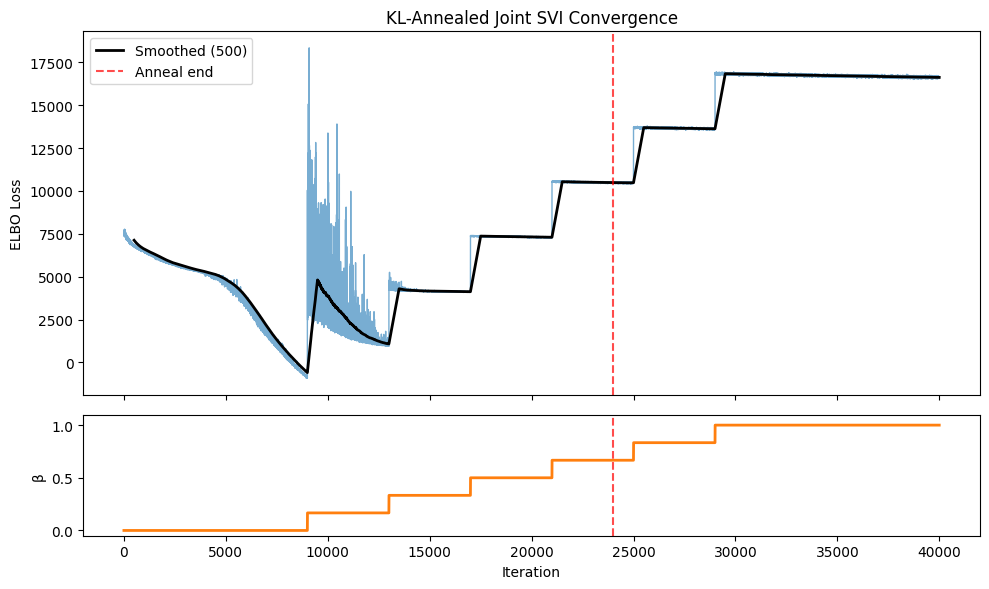

In [52]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})

# ELBO loss
ax1.plot(svi_result.losses, lw=1, alpha=0.6)
# Smoothed loss for readability
window = min(500, len(svi_result.losses) // 10)
if window > 1:
    smoothed = np.convolve(svi_result.losses, np.ones(window)/window, mode='valid')
    ax1.plot(np.arange(window-1, window-1+len(smoothed)), smoothed, 'k-', lw=2, label=f'Smoothed ({window})')
anneal_end = int(NUM_SVI_STEPS * ANNEAL_FRACTION)
ax1.axvline(anneal_end, color='red', ls='--', lw=1.5, alpha=0.7, label='Anneal end')
ax1.set_ylabel('ELBO Loss')
ax1.set_title('KL-Annealed Joint SVI Convergence')
ax1.legend()

# β schedule
ax2.plot(svi_result.betas, 'tab:orange', lw=2)
ax2.axvline(anneal_end, color='red', ls='--', lw=1.5, alpha=0.7)
ax2.set_xlabel('Iteration')
ax2.set_ylabel('β')
ax2.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

In [53]:
samples = svi_result.samples

print("Inferred GP Hyperparameters (median):")
for i in range(NUM_MODES):
    L_i = np.median(samples[f'lengthscale_{i}'])
    V_i = np.median(samples[f'variance_{i}'])
    N_i = np.median(samples[f'noise_{i}'])
    print(f"  Mode {i}: L={L_i:.4f}, V={V_i:.4f}, N={N_i:.6f}")

if LEARN_GAMMA2:
    print("\nInferred ODE constraint slack \u03b3\u2082 (median):")
    for i in range(NUM_MODES):
        g2_i = np.median(samples[f'gamma2_{i}'])
        print(f"  Mode {i}: \u03b3\u2082={g2_i:.4f}")

Inferred GP Hyperparameters (median):
  Mode 0: L=0.0046, V=1.7365, N=0.000704
  Mode 1: L=0.0044, V=2.2531, N=0.000983
  Mode 2: L=0.0045, V=1.9090, N=0.000704
  Mode 3: L=0.0051, V=1.7640, N=0.000907
  Mode 4: L=0.0042, V=2.7185, N=0.001095
  Mode 5: L=0.0038, V=1.8458, N=0.002435

Inferred ODE constraint slack γ₂ (median):
  Mode 0: γ₂=53618.7031
  Mode 1: γ₂=100089.1250
  Mode 2: γ₂=78659.9688
  Mode 3: γ₂=55028.2656
  Mode 4: γ₂=145963.6250
  Mode 5: γ₂=127184.0859


## 4. Diagnostic Plots

### Plot 1: GP Fit

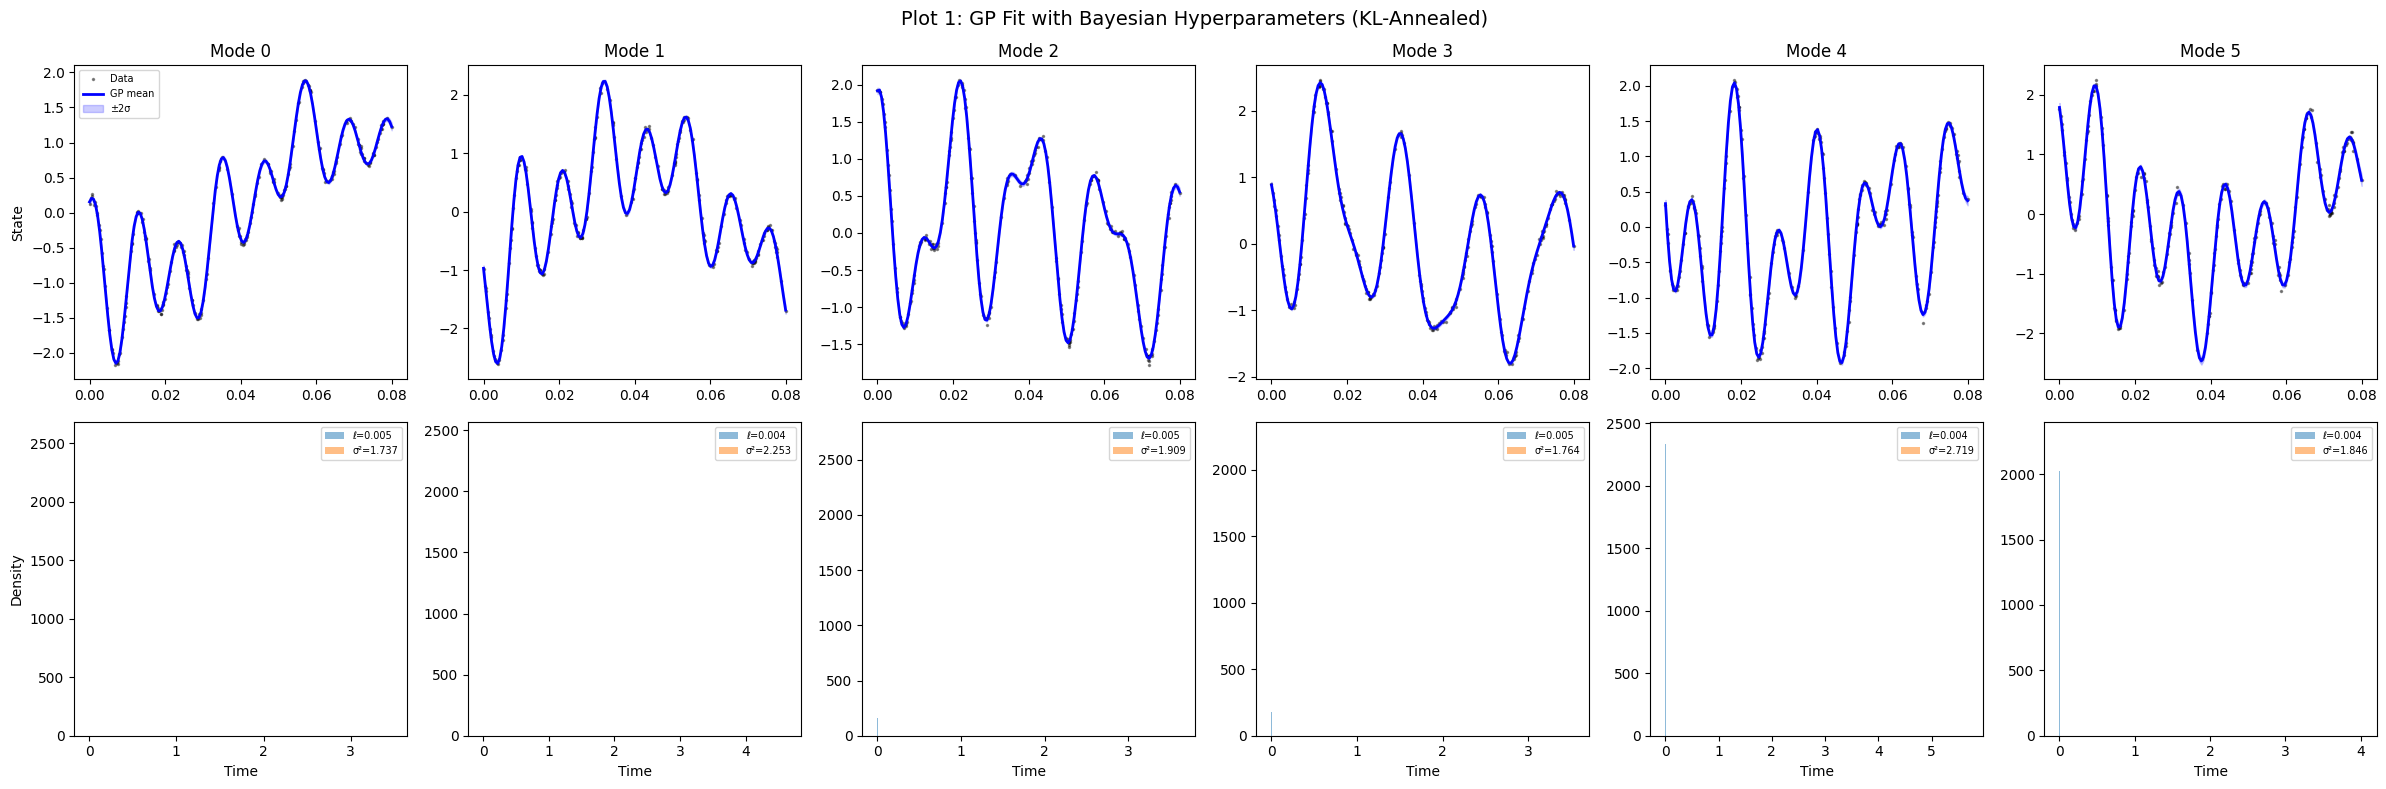

In [54]:
gp_means, gp_stds, Ls, Vs, Ns = extract_gp_posterior(
    samples, NUM_MODES, time_sampled, time_domain_eval_training, training_data,
)

fig, axes = plt.subplots(2, NUM_MODES, figsize=(4 * NUM_MODES, 8))
if NUM_MODES == 1:
    axes = axes[:, np.newaxis]

for i in range(NUM_MODES):
    ax = axes[0, i]
    ax.plot(time_sampled, training_data[i], 'k.', ms=3, alpha=0.4, label='Data')
    ax.plot(time_domain_eval_training, gp_means[i], 'b-', lw=2, label='GP mean')
    ax.fill_between(
        time_domain_eval_training,
        gp_means[i] - 2 * gp_stds[i],
        gp_means[i] + 2 * gp_stds[i],
        alpha=0.2, color='blue', label='\u00b12\u03c3',
    )
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('State')
        ax.legend(fontsize=7)

    ax2 = axes[1, i]
    ax2.hist(np.array(samples[f'lengthscale_{i}']), bins=30, alpha=0.5, label=f'\u2113={Ls[i]:.3f}', density=True)
    ax2.hist(np.array(samples[f'variance_{i}']), bins=30, alpha=0.5, label=f'\u03c3\u00b2={Vs[i]:.3f}', density=True)
    ax2.legend(fontsize=7)
    if i == 0:
        ax2.set_ylabel('Density')
    ax2.set_xlabel('Time')

fig.suptitle('Plot 1: GP Fit with Bayesian Hyperparameters (KL-Annealed)', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 2: Derivative GP Fit

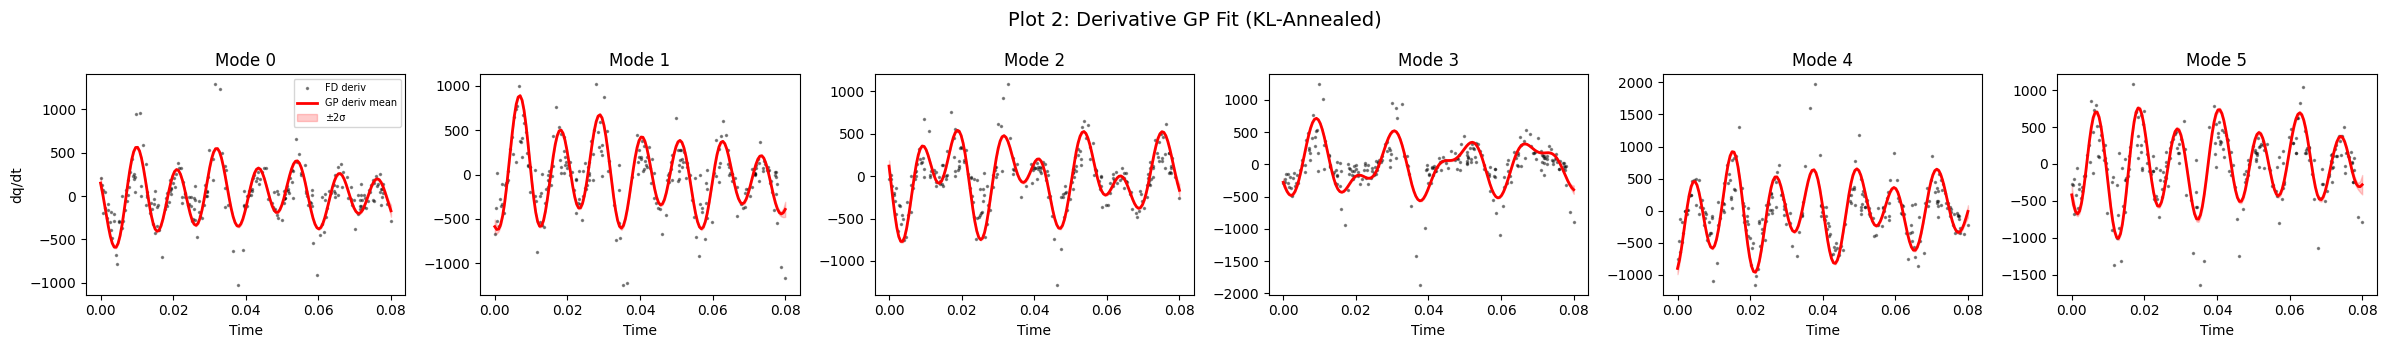

In [55]:
mu_z, std_z = extract_derivative_posterior(
    Ls, Vs, Ns, time_sampled, time_domain_eval_training, training_data,
)

fd_derivs = compute_derivatives_fourth_order(training_data, time_sampled)

fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_sampled, fd_derivs[i], 'k.', ms=3, alpha=0.4, label='FD deriv')
    ax.plot(time_domain_eval_training, mu_z[i], 'r-', lw=2, label='GP deriv mean')
    ax.fill_between(
        time_domain_eval_training,
        mu_z[i] - 2 * std_z[i],
        mu_z[i] + 2 * std_z[i],
        alpha=0.2, color='red', label='\u00b12\u03c3',
    )
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('dq/dt')
        ax.legend(fontsize=7)
    ax.set_xlabel('Time')

fig.suptitle('Plot 2: Derivative GP Fit (KL-Annealed)', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 3: GP-based OpInf Integration (Baseline)

Grid search: testing 41 regularization values...
  reg=1.0e-16: UNSTABLE
  reg=3.2e-16: UNSTABLE
  reg=1.0e-15: UNSTABLE
  reg=3.2e-15: UNSTABLE
  reg=1.0e-14: UNSTABLE
  reg=3.2e-14: UNSTABLE
  reg=1.0e-13: UNSTABLE
  reg=3.2e-13: UNSTABLE
  reg=1.0e-12: UNSTABLE
  reg=3.2e-12: UNSTABLE
  reg=1.0e-11: UNSTABLE
  reg=3.2e-11: UNSTABLE
  reg=1.0e-10: UNSTABLE
  reg=3.2e-10: UNSTABLE
  reg=1.0e-09: UNSTABLE
  reg=3.2e-09: UNSTABLE
  reg=1.0e-08: UNSTABLE
  reg=3.2e-08: UNSTABLE
  reg=1.0e-07: UNSTABLE
  reg=3.2e-07: UNSTABLE
  reg=1.0e-06: UNSTABLE
  reg=3.2e-06: UNSTABLE
  reg=1.0e-05: UNSTABLE
  reg=3.2e-05: UNSTABLE
  reg=1.0e-04: UNSTABLE
  reg=3.2e-04: UNSTABLE
  reg=1.0e-03: UNSTABLE
  reg=3.2e-03: UNSTABLE
  reg=1.0e-02: UNSTABLE
  reg=3.2e-02: UNSTABLE
  reg=1.0e-01: UNSTABLE
  reg=3.2e-01: STABLE, error=0.136753
  reg=1.0e+00: STABLE, error=0.141445
  reg=3.2e+00: STABLE, error=0.520337
  reg=1.0e+01: STABLE, error=1.186990
  reg=3.2e+01: STABLE, error=1.446530
  reg=1.0e+02: ST

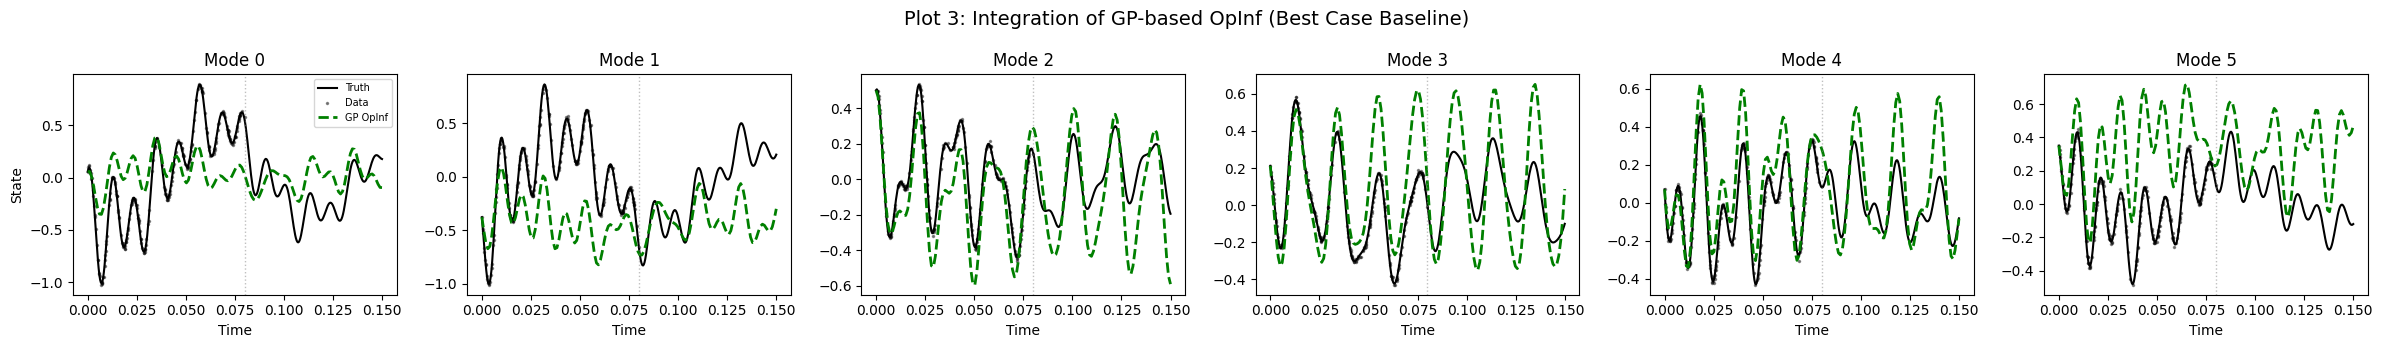

In [56]:
gp_means_train, _, _, _, _ = extract_gp_posterior(
    samples, NUM_MODES, time_sampled, time_sampled, training_data,
)

gp_baseline_result = gp_based_opinf_baseline(
    basis=basis,
    gp_means=gp_means_train,
    time_eval=time_sampled,
    snapshots_compressed=snapshots_comp_sampled,
    operators=OPERATORS,
    inputs=None,
    input_func=None,
    ivp_method=IVP_METHOD,
)
print(f"GP baseline reg: {gp_baseline_result.best_reg:.2e}, error: {gp_baseline_result.best_error:.4%}")

gp_baseline_rom = gp_baseline_result.rom
gp_baseline_rom.model._extract_operators(np.array(gp_baseline_result.operator))
try:
    gp_pred = gp_baseline_rom.model.predict(
        state0=snapshots_comp_sampled[:, 0],
        t=time_domain_eval_prediction,
    )
    gp_pred_sol = gp_baseline_rom.model.predict_result_
    gp_baseline_stable = gp_pred_sol.y.shape[1] >= len(time_domain_eval_prediction)
except Exception:
    gp_baseline_stable = False

fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_domain_full, full_states_compressed[i], 'k-', lw=1.5, label='Truth')
    ax.plot(time_sampled, snapshots_comp_sampled[i], 'k.', ms=3, alpha=0.4, label='Data')
    if gp_baseline_stable:
        ax.plot(time_domain_eval_prediction, gp_pred_sol.y[i], 'g--', lw=2, label='GP OpInf')
    ax.axvline(TRAINING_SPAN[1], color='gray', ls=':', lw=1, alpha=0.5)
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('State')
        ax.legend(fontsize=7)
    ax.set_xlabel('Time')

fig.suptitle('Plot 3: Integration of GP-based OpInf (Best Case Baseline)', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 4: Latent State Fit

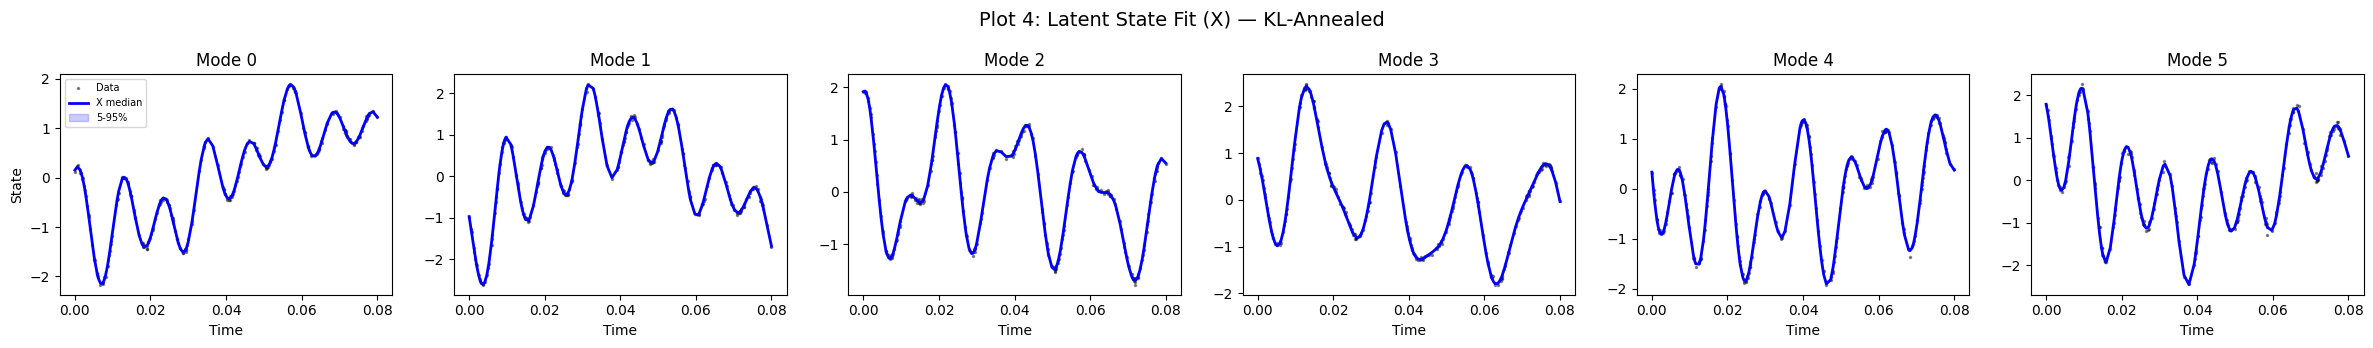

In [57]:
fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    X_i = np.array(samples[f'X_{i}'])
    X_median = np.median(X_i, axis=0)
    X_q05 = np.percentile(X_i, 5, axis=0)
    X_q95 = np.percentile(X_i, 95, axis=0)

    ax.plot(time_sampled, training_data[i], 'k.', ms=3, alpha=0.4, label='Data')
    ax.plot(time_sampled, X_median, 'b-', lw=2, label='X median')
    ax.fill_between(time_sampled, X_q05, X_q95, alpha=0.2, color='blue', label='5-95%')
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('State')
        ax.legend(fontsize=7)
    ax.set_xlabel('Time')

fig.suptitle('Plot 4: Latent State Fit (X) — KL-Annealed', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 5: Derivative Operator Fit

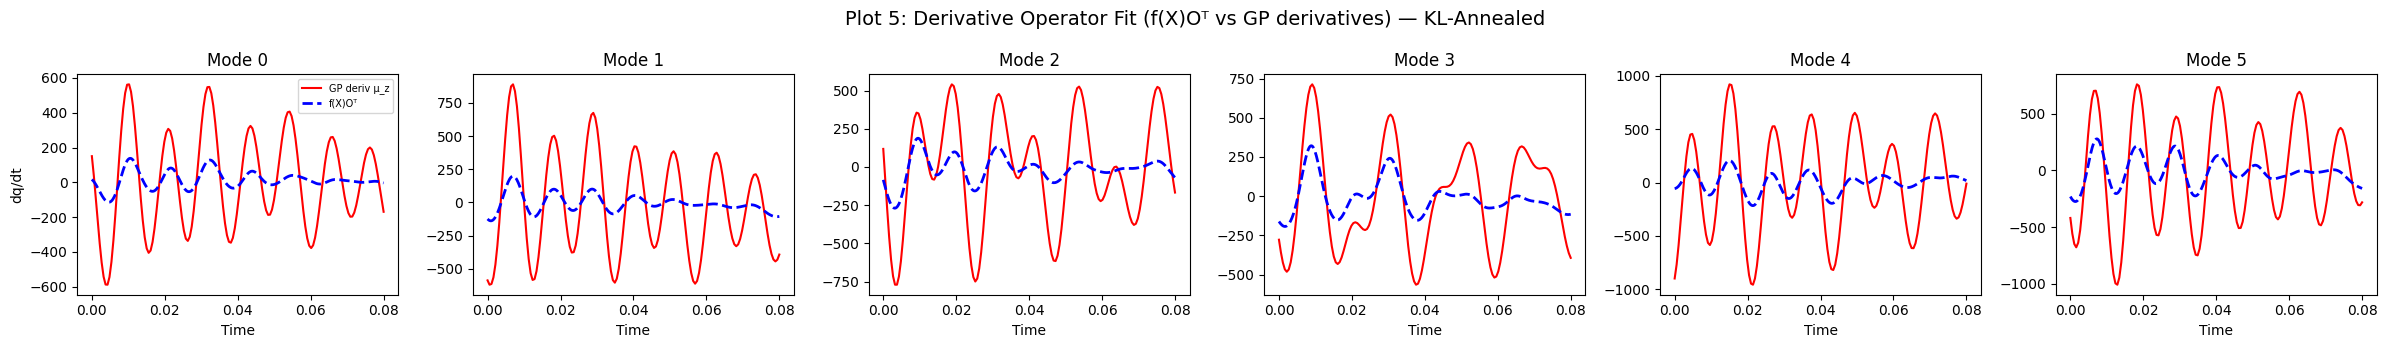

In [58]:
O_samples = _find_operator_samples(samples, "O")
if O_samples.ndim == 2:
    O_samples = O_samples[np.newaxis, ...]

O_median = np.median(O_samples, axis=0)

if f'X_eval_0' in samples:
    Xs_eval_median = np.array([np.median(samples[f'X_eval_{i}'], axis=0) for i in range(NUM_MODES)])
else:
    Xs_eval_median = np.array([np.median(samples[f'X_{i}'], axis=0) for i in range(NUM_MODES)])

if USE_SCALED_DATA and data_scaler is not None:
    Xs_eval_orig = np.array([
        Xs_eval_median[i] * data_scaler.stds_[i, 0] + data_scaler.means_[i, 0]
        for i in range(NUM_MODES)
    ])
else:
    Xs_eval_orig = Xs_eval_median

f_X = np.array(rom.model._assemble_data_matrix(jnp.array(Xs_eval_orig), inputs=None) @ jnp.array(O_median).T)
if USE_SCALED_DATA and data_scaler is not None:
    f_X_scaled = np.array([f_X.T[i] / data_scaler.stds_[i, 0] for i in range(NUM_MODES)])
else:
    f_X_scaled = f_X.T

t_eval_plot = time_eval if f'X_eval_0' in samples else time_sampled

fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_domain_eval_training, mu_z[i], 'r-', lw=1.5, label='GP deriv \u03bc_z')
    ax.plot(t_eval_plot, f_X_scaled[i], 'b--', lw=2, label='f(X)O\u1d40')
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('dq/dt')
        ax.legend(fontsize=7)
    ax.set_xlabel('Time')

fig.suptitle('Plot 5: Derivative Operator Fit (f(X)O\u1d40 vs GP derivatives) — KL-Annealed', fontsize=14)
plt.tight_layout()
plt.show()

### Plot 6: Integrated Operator Fit (ROM Predictions)

Operator samples: 200, Stable solves: 17


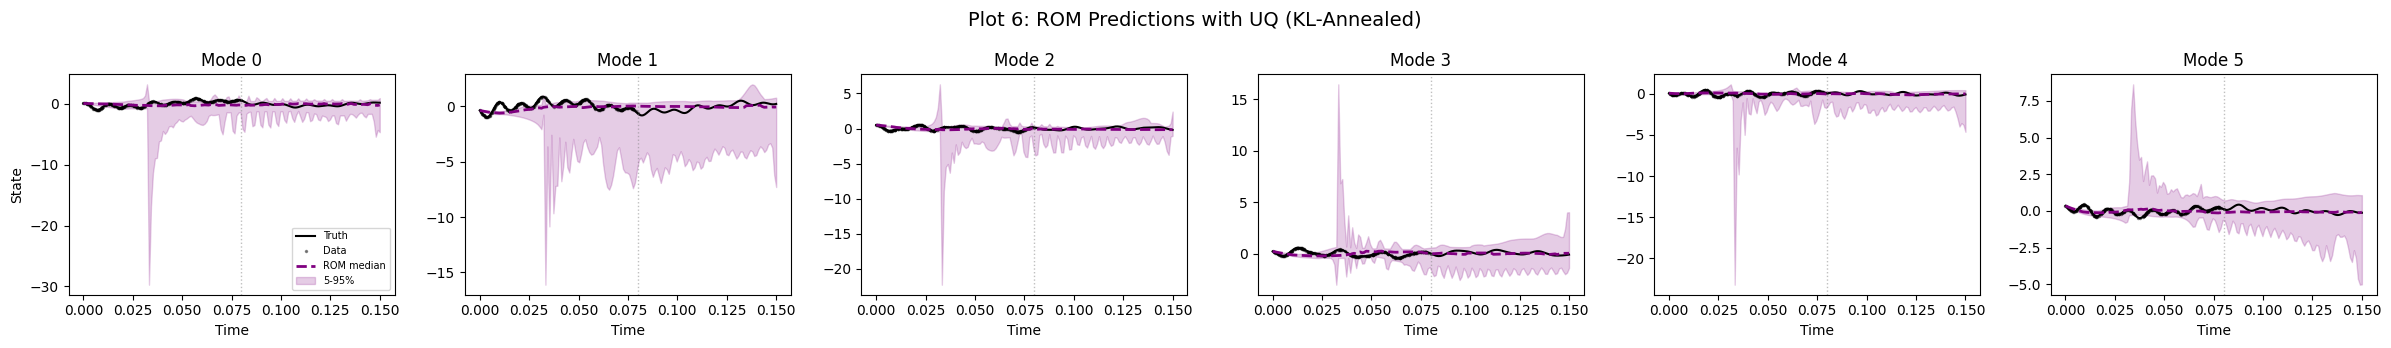

In [59]:
Os, Xs, rom_solves = generate_rom_predictions(
    samples=samples, rom=rom,
    snapshots_compressed=snapshots_comp_sampled,
    time_eval=time_domain_eval_prediction,
    num_modes=NUM_MODES, num_pulls=200,
    input_func=None,
    data_scaler=data_scaler if USE_SCALED_DATA else None,
    ivp_method=IVP_METHOD,
)
print(f"Operator samples: {len(Os)}, Stable solves: {len(rom_solves)}")

fig, axes = plt.subplots(1, NUM_MODES, figsize=(4 * NUM_MODES, 3.5), sharex=True)
if NUM_MODES == 1:
    axes = [axes]

for i in range(NUM_MODES):
    ax = axes[i]
    ax.plot(time_domain_full, full_states_compressed[i], 'k-', lw=1.5, label='Truth')
    ax.plot(time_sampled, snapshots_comp_sampled[i], 'k.', ms=3, alpha=0.4, label='Data')

    if len(rom_solves) > 0:
        rom_arr = np.array(rom_solves)
        median = np.median(rom_arr[:, i, :], axis=0)
        q05 = np.percentile(rom_arr[:, i, :], 5, axis=0)
        q95 = np.percentile(rom_arr[:, i, :], 95, axis=0)
        ax.plot(time_domain_eval_prediction, median, 'purple', ls='--', lw=2, label='ROM median')
        ax.fill_between(time_domain_eval_prediction, q05, q95, alpha=0.2, color='purple', label='5-95%')

    ax.axvline(TRAINING_SPAN[1], color='gray', ls=':', lw=1, alpha=0.5)
    ax.set_title(f'Mode {i}')
    if i == 0:
        ax.set_ylabel('State')
        ax.legend(fontsize=7)
    ax.set_xlabel('Time')

fig.suptitle('Plot 6: ROM Predictions with UQ (KL-Annealed)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Summary

In [60]:
print("=" * 60)
print("EXPERIMENT SUMMARY: Euler — KL-Annealed Joint Bayesian")
print("=" * 60)
print(f"Operators: {OPERATORS}")
print(f"Modes: {NUM_MODES}")
print(f"Training span: [{TRAINING_SPAN[0]}, {TRAINING_SPAN[1]}]")
print(f"Prediction span: [{PREDICTION_SPAN[0]}, {PREDICTION_SPAN[1]}]")
print(f"Scaling: {'enabled' if USE_SCALED_DATA else 'disabled'}")
print(f"Gamma (operator): {GAMMA}")
print(f"Gamma2 (ODE): {GAMMA2}")
print(f"Guide: {GUIDE.__name__}")
print(f"SVI steps: {NUM_SVI_STEPS}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"\nKL Annealing:")
print(f"  Schedule: {ANNEAL_SCHEDULE}")
print(f"  β: {BETA_START} → 1.0 over {ANNEAL_FRACTION:.0%} of steps")
print(f"  Anneal window: 0 → {int(NUM_SVI_STEPS * ANNEAL_FRACTION)} steps")
print(f"\nInferred GP Hyperparameters:")
for i in range(NUM_MODES):
    print(f"  Mode {i}: L={Ls[i]:.4f}, V={Vs[i]:.4f}, N={Ns[i]:.6f}")
print(f"\nOperator samples: {len(Os)}")
print(f"Stable ROM solves: {len(rom_solves)}")
print(f"Algorithm runtime: {algo_time:.1f}s ({algo_time/60:.1f}min)")

EXPERIMENT SUMMARY: Euler — KL-Annealed Joint Bayesian
Operators: cAH
Modes: 6
Training span: [0, 0.08]
Prediction span: [0, 0.15]
Scaling: enabled
Gamma (operator): 10000.0
Gamma2 (ODE): 10.0
Guide: AutoNormal
SVI steps: 40000
Learning rate: 0.001

KL Annealing:
  Schedule: stepwise
  β: 0.0 → 1.0 over 60% of steps
  Anneal window: 0 → 24000 steps

Inferred GP Hyperparameters:
  Mode 0: L=0.0046, V=1.7365, N=0.000704
  Mode 1: L=0.0044, V=2.2531, N=0.000983
  Mode 2: L=0.0045, V=1.9090, N=0.000704
  Mode 3: L=0.0051, V=1.7640, N=0.000907
  Mode 4: L=0.0042, V=2.7185, N=0.001095
  Mode 5: L=0.0038, V=1.8458, N=0.002435

Operator samples: 200
Stable ROM solves: 17
Algorithm runtime: 2431.9s (40.5min)
